# Лабораторная работа №1
## Освоение базового ML-пайплайна на табличных данных

**Выполнил:** Соколов Александр Сергеевич  
**Дисциплина:** Фреймворки машинного обучения  
**Датасет:** [Student Depression and Lifestyle — 100k](https://www.kaggle.com/datasets/aldinwhyudii/student-depression-and-lifestyle-100k-data)

**Задача 1 (регрессия):** предсказать CGPA (шкала 0–4) по режиму занятий и сна  
**Задача 2 (классификация):** определить риск депрессии по образу жизни и уровню стресса

# 0. Импорты

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, r2_score,
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, confusion_matrix, ConfusionMatrixDisplay,
)
from sklearn.feature_selection import mutual_info_regression, mutual_info_classif

sns.set_theme(style='whitegrid')
SEED = 42
np.random.seed(SEED)

# 1. Разведочный анализ данных (EDA)

In [2]:
try:
    df = pd.read_csv('student_lifestyle_100k.csv')
except FileNotFoundError:
    df = pd.read_csv('/kaggle/input/student-depression-and-lifestyle-100k-data/student_lifestyle_100k.csv')

df_raw = df.copy()
print(f'Размер датасета: {df.shape}')
df.head()

Размер датасета: (100000, 11)


,Student_ID,Age,Gender,Department,CGPA,Sleep_Duration,Study_Hours,Social_Media_Hours,Physical_Activity,Stress_Level,Depression
0,1001,22,Female,Science,3.50,7.3,3.3,3.4,114,5,False
1,1002,20,Male,Engineering,2.72,5.5,7.2,6.0,142,2,False
2,1003,20,Male,Medical,3.01,5.4,2.3,1.8,137,3,False
3,1004,21,Male,Engineering,3.63,8.1,2.0,4.6,130,3,False
4,1005,19,Male,Arts,3.14,6.8,2.6,4.3,4,6,False


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 11 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   Student_ID          100000 non-null  int64  
 1   Age                 100000 non-null  int64  
 2   Gender              100000 non-null  str    
 3   Department          100000 non-null  str    
 4   CGPA                100000 non-null  float64
 5   Sleep_Duration      100000 non-null  float64
 6   Study_Hours         100000 non-null  float64
 7   Social_Media_Hours  100000 non-null  float64
 8   Physical_Activity   100000 non-null  int64  
 9   Stress_Level        100000 non-null  int64  
 10  Depression          100000 non-null  bool   
dtypes: bool(1), float64(4), int64(4), str(2)
memory usage: 7.7 MB


In [4]:
df.describe(include='all')

,Student_ID,Age,Gender,Department,CGPA,Sleep_Duration,Study_Hours,Social_Media_Hours,Physical_Activity,Stress_Level,Depression
count,100000.000000,100000.000000,100000,100000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000
unique,NaN,NaN,2,5,NaN,NaN,NaN,NaN,NaN,NaN,2
top,NaN,NaN,Male,Science,NaN,NaN,NaN,NaN,NaN,NaN,False
freq,NaN,NaN,50120,20071,NaN,NaN,NaN,NaN,NaN,NaN,89938
mean,51000.500000,21.009010,NaN,NaN,2.898316,6.996425,4.509517,3.503288,74.353180,4.131660,NaN
std,28867.657797,2.000382,NaN,NaN,0.532240,1.498682,1.976076,1.486852,43.366963,1.424151,NaN
min,1001.000000,18.000000,NaN,NaN,1.560000,3.000000,0.000000,0.000000,0.000000,2.000000,NaN
25%,26000.750000,19.000000,NaN,NaN,2.450000,6.000000,3.200000,2.500000,37.000000,3.000000,NaN
50%,51000.500000,21.000000,NaN,NaN,2.900000,7.000000,4.500000,3.500000,74.000000,4.000000,NaN
75%,76000.250000,23.000000,NaN,NaN,3.350000,8.000000,5.800000,4.500000,112.000000,5.000000,NaN


In [5]:
print('Пропущенные значения:')
print(df.isnull().sum())
print('\nДубликатов:', df.duplicated().sum())
print('\nУникальные Gender:', df.Gender.unique())
if 'Department' in df.columns:
    print('Уникальные Department:', df['Department'].dropna().unique())


Пропущенные значения:
Student_ID            0
Age                   0
Gender                0
Department            0
CGPA                  0
Sleep_Duration        0
Study_Hours           0
Social_Media_Hours    0
Physical_Activity     0
Stress_Level          0
Depression            0
dtype: int64

Дубликатов: 0

Уникальные Gender: <StringArray>
['Female', 'Male']
Length: 2, dtype: str
Уникальные Department: <StringArray>
['Science', 'Engineering', 'Medical', 'Arts', 'Business']
Length: 5, dtype: str


## 1.1 Первичный осмотр

## 1.2 Пропущенные значения

In [6]:
miss = (df.isnull().sum() / len(df) * 100).round(1)
miss = miss[miss > 0].sort_values(ascending=False)

if miss.empty:
    print('Пропущенных значений нет — датасет полный.')
else:
    fig, ax = plt.subplots(figsize=(8, 3))
    miss.plot.barh(ax=ax, color='steelblue')
    ax.set_xlabel('% пропусков')
    ax.set_title('Доля пропущенных значений по столбцам')
    for i, v in enumerate(miss):
        ax.text(v + 0.1, i, f'{v}%', va='center')
    plt.tight_layout()
    plt.show()

Пропущенных значений нет — датасет полный.


## 1.3 Выбросы и логические ошибки

In [7]:
print(f'Age вне [18, 30]:               {((df.Age < 18) | (df.Age > 30)).sum()} строк')
print(f'Sleep_Duration вне [0, 24]:     {((df.Sleep_Duration < 0) | (df.Sleep_Duration > 24)).sum()} строк')
print(f'CGPA вне [0, 4]:                {((df.CGPA < 0) | (df.CGPA > 4)).sum()} строк')
print(f'Study_Hours вне [0, 24]:        {((df.Study_Hours < 0) | (df.Study_Hours > 24)).sum()} строк')
print(f'Physical_Activity вне [0, 200]: {((df.Physical_Activity < 0) | (df.Physical_Activity > 200)).sum()} строк')
print(f'Social_Media_Hours вне [0,24]:  {((df.Social_Media_Hours < 0) | (df.Social_Media_Hours > 24)).sum()} строк')
print(f'Stress_Level вне [1, 10]:       {((df.Stress_Level < 1) | (df.Stress_Level > 10)).sum()} строк')

Age вне [18, 30]:               0 строк
Sleep_Duration вне [0, 24]:     0 строк
CGPA вне [0, 4]:                0 строк
Study_Hours вне [0, 24]:        0 строк
Physical_Activity вне [0, 200]: 0 строк
Social_Media_Hours вне [0,24]:  0 строк
Stress_Level вне [1, 10]:       0 строк


## 1.4 Распределения числовых признаков

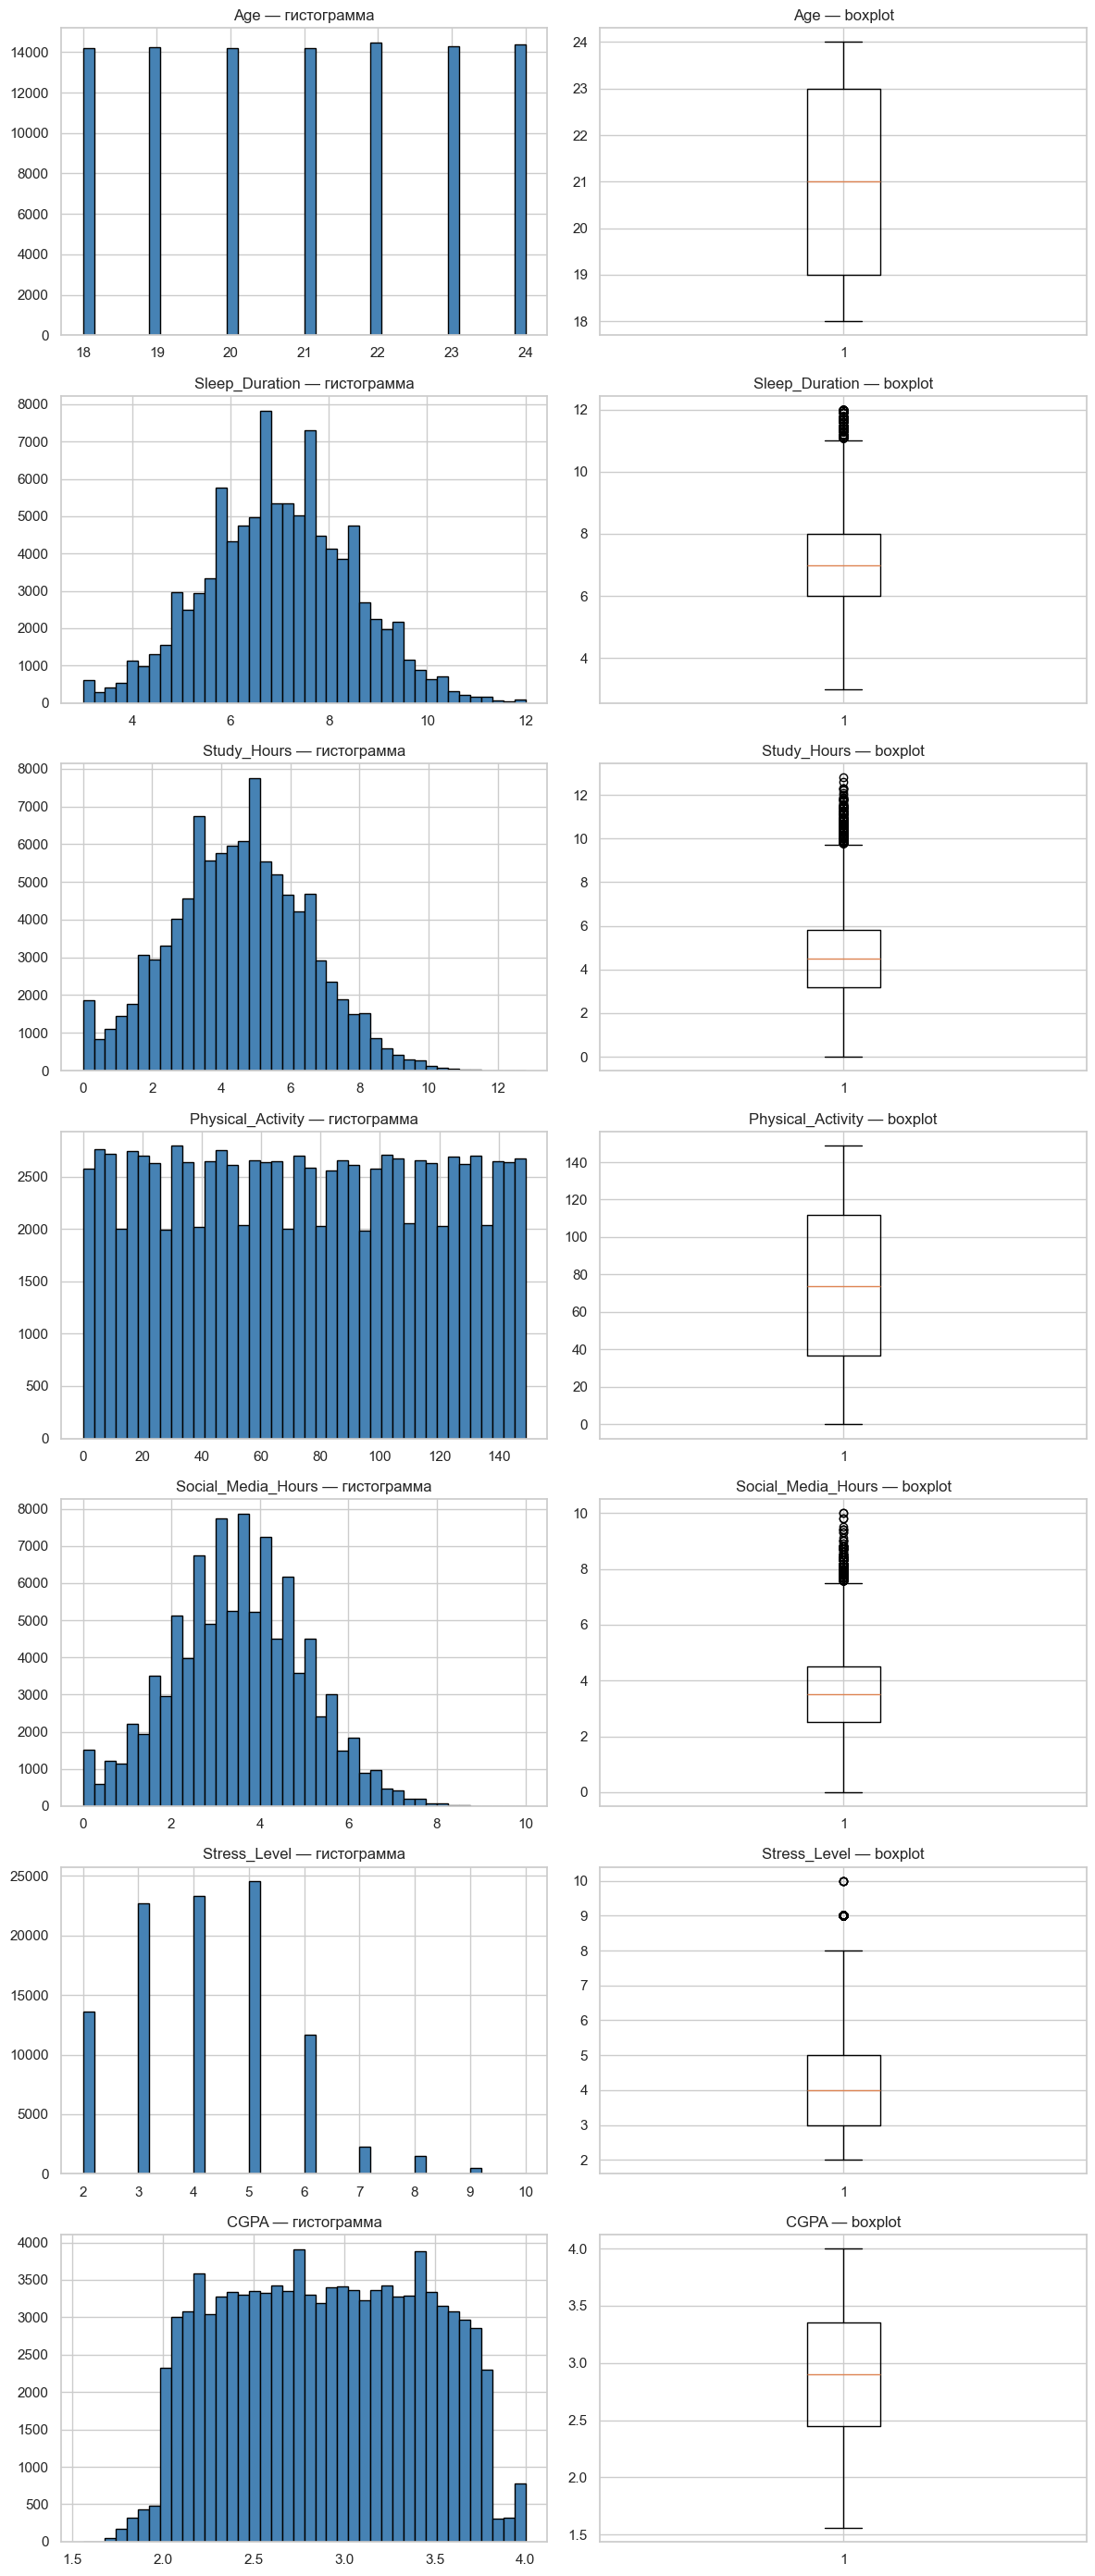

In [8]:
num_cols = ['Age', 'Sleep_Duration', 'Study_Hours', 'Physical_Activity',
            'Social_Media_Hours', 'Stress_Level', 'CGPA']

fig, axes = plt.subplots(len(num_cols), 2, figsize=(12, 4 * len(num_cols)))
for i, col in enumerate(num_cols):
    axes[i, 0].hist(df[col].dropna(), bins=40, edgecolor='black', color='steelblue')
    axes[i, 0].set_title(f'{col} — гистограмма')
    axes[i, 1].boxplot(df[col].dropna())
    axes[i, 1].set_title(f'{col} — boxplot')
plt.tight_layout()
plt.show()

## 1.5 Категориальные признаки

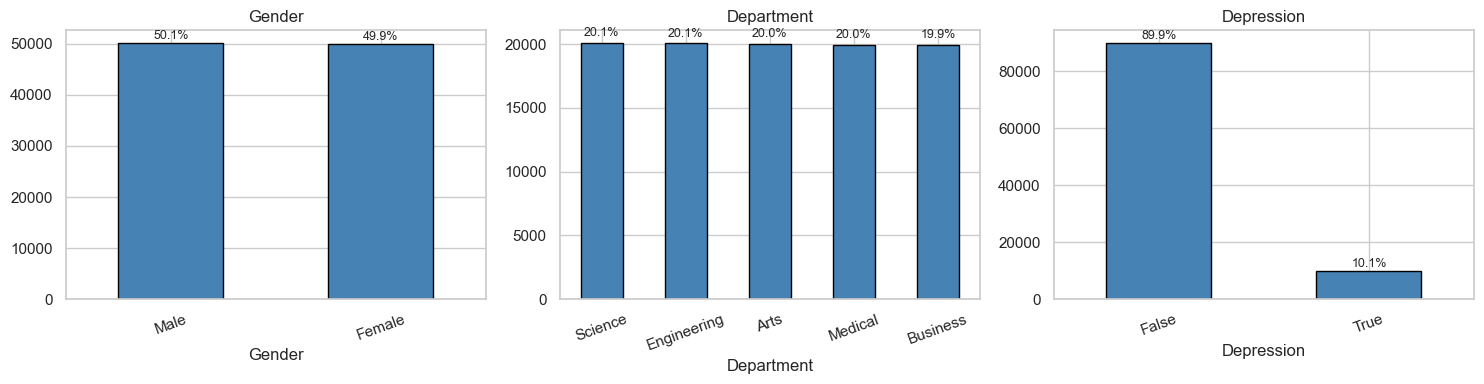

Доля классов Depression:
Depression
False    0.899
True     0.101
Name: proportion, dtype: float64


In [9]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, ['Gender', 'Department', 'Depression']):
    counts = df[col].value_counts()
    counts.plot.bar(ax=ax, color='steelblue', edgecolor='black')
    ax.set_title(col)
    ax.tick_params(axis='x', rotation=20)
    total = counts.sum()
    for p, v in zip(ax.patches, counts):
        ax.text(p.get_x() + p.get_width() / 2,
                p.get_height() + total * 0.003,
                f'{v / total:.1%}', ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.show()

print('Доля классов Depression:')
print(df['Depression'].value_counts(normalize=True).round(3))

## 1.6 Корреляция (Pearson и Spearman)

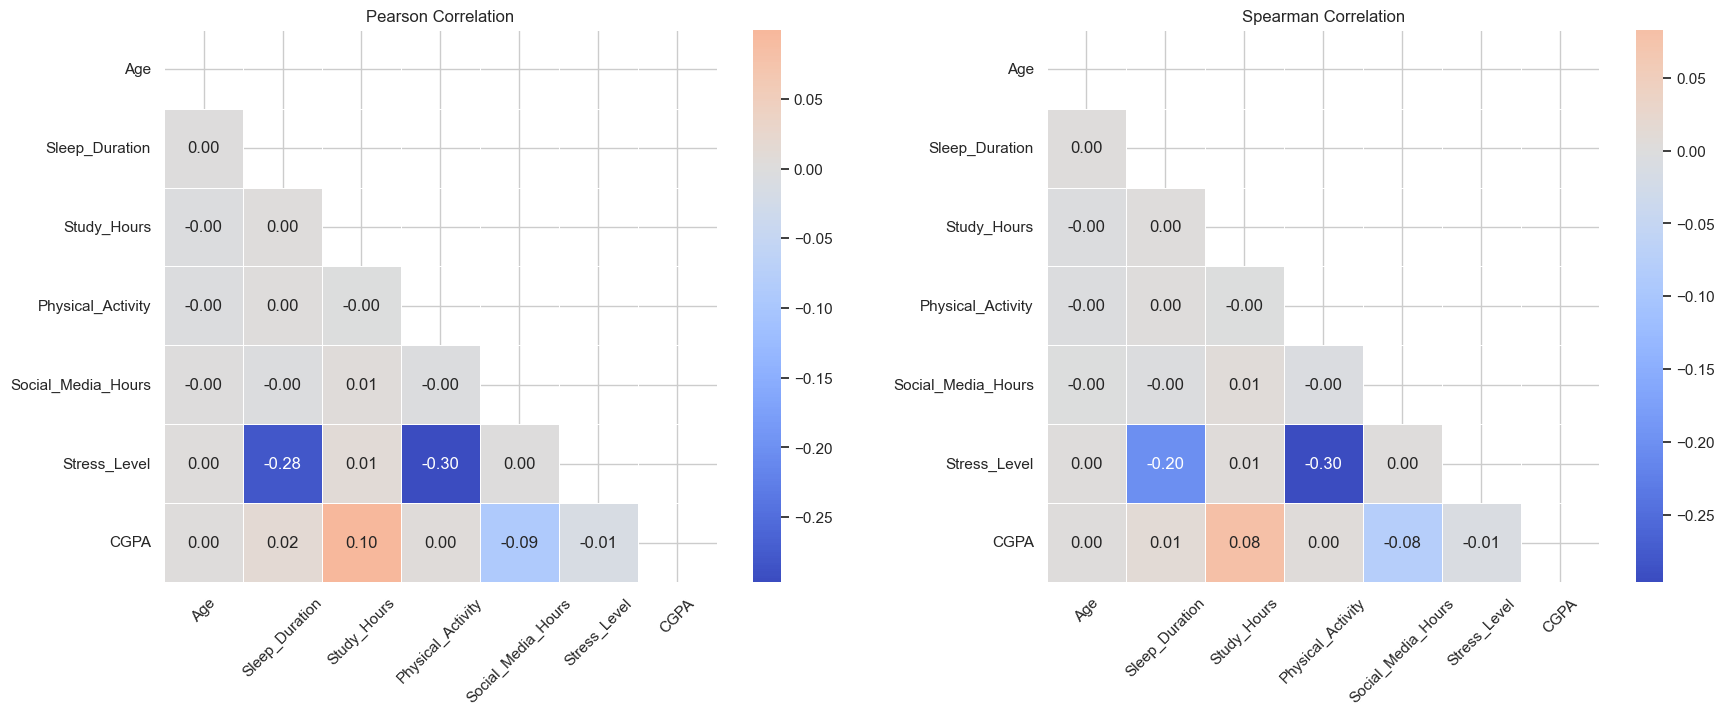

In [10]:
pearson_corr  = df[num_cols].corr(method='pearson')
spearman_corr = df[num_cols].corr(method='spearman')
mask = np.triu(np.ones_like(pearson_corr, dtype=bool))

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
sns.heatmap(pearson_corr,  mask=mask, annot=True, fmt='.2f',
            cmap='coolwarm', center=0, square=True, linewidths=0.5, ax=axes[0])
axes[0].set_title('Pearson Correlation')
axes[0].tick_params(axis='x', rotation=45)

sns.heatmap(spearman_corr, mask=mask, annot=True, fmt='.2f',
            cmap='coolwarm', center=0, square=True, linewidths=0.5, ax=axes[1])
axes[1].set_title('Spearman Correlation')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

## 1.7 Связь признаков с целевыми переменными

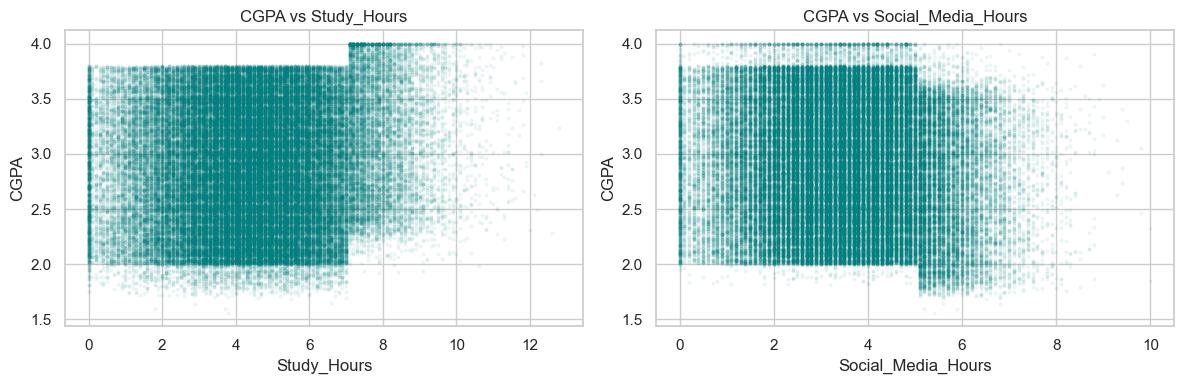

Pearson корреляции с CGPA:
Social_Media_Hours   -0.0880
Stress_Level         -0.0123
Physical_Activity     0.0048
Sleep_Duration        0.0154
Study_Hours           0.0995
Name: CGPA, dtype: float64


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, col in zip(axes, ['Study_Hours', 'Social_Media_Hours']):
    ax.scatter(df[col], df['CGPA'], alpha=0.05, s=4, color='teal')
    ax.set_xlabel(col)
    ax.set_ylabel('CGPA')
    ax.set_title(f'CGPA vs {col}')
plt.tight_layout()
plt.show()

print('Pearson корреляции с CGPA:')
num_cols_corr = ['Study_Hours', 'Social_Media_Hours', 'Sleep_Duration', 'Stress_Level', 'Physical_Activity']
print(df[num_cols_corr + ['CGPA']].corr()['CGPA'].drop('CGPA').sort_values().round(4))

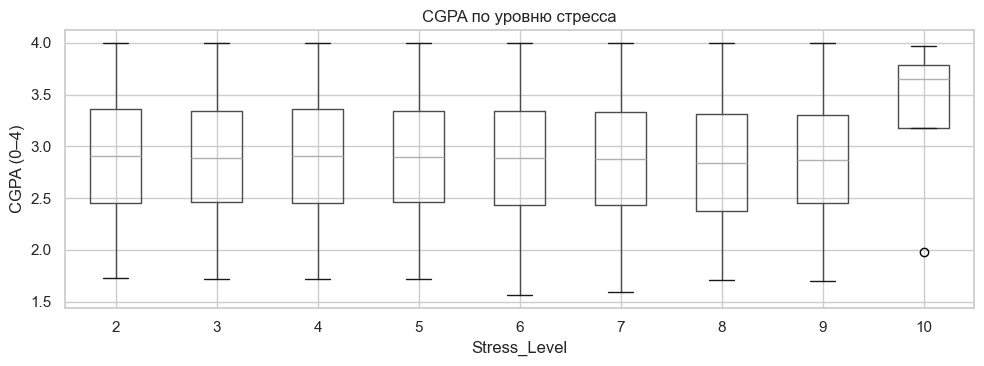

In [12]:
fig, ax = plt.subplots(figsize=(10, 4))
df.boxplot('CGPA', by='Stress_Level', ax=ax)
ax.set_title('CGPA по уровню стресса')
ax.set_xlabel('Stress_Level')
ax.set_ylabel('CGPA (0–4)')
plt.suptitle('')
plt.tight_layout()
plt.show()

# 2. Предобработка

Датасет уже достаточно чистый (нет пропусков, нет посторонних столбцов), поэтому предобработка сводится к нормализации типов и кодированию.

| Проблема | Решение | Обоснование |
|---|---|---|
| `Student_ID` — идентификатор | удаление | не несёт предсказательной силы |
| `Depression` — boolean | int(0/1) | требование sklearn |
| `Gender` — бинарный | int(0/1) | Female=1, Male=0 |
| `Department` — номинальный | One-Hot (drop_first) | нет порядка между факультетами |
| Нереалистичные значения | замена на NaN | контроль диапазонов (CGPA 0–4, Sleep 0–24 и т.д.) |
| Пропуски в числовых столбцах | медиана | устойчива к выбросам |
| Пропуски в категориальных | мода | базовое и интерпретируемое решение |

## 2.1 Дубликаты и мусорные столбцы

In [13]:
df = df_raw.copy()

before = len(df)
df = df.drop_duplicates()
print(f'Удалено дубликатов: {before - len(df)}')

df = df.drop(columns=['Student_ID'])
print(f'Столбцов осталось: {df.shape[1]}')

Удалено дубликатов: 0


Столбцов осталось: 10


## 2.2 Логические ошибки → NaN

In [14]:
df.loc[(df.Age < 18) | (df.Age > 30), 'Age'] = np.nan
df.loc[(df.Sleep_Duration < 0) | (df.Sleep_Duration > 24), 'Sleep_Duration'] = np.nan
df.loc[(df.CGPA < 0) | (df.CGPA > 4), 'CGPA'] = np.nan
df.loc[(df.Study_Hours < 0) | (df.Study_Hours > 24), 'Study_Hours'] = np.nan
df.loc[(df.Physical_Activity < 0) | (df.Physical_Activity > 200), 'Physical_Activity'] = np.nan
df.loc[(df.Social_Media_Hours < 0) | (df.Social_Media_Hours > 24), 'Social_Media_Hours'] = np.nan
df.loc[(df.Stress_Level < 1) | (df.Stress_Level > 10), 'Stress_Level'] = np.nan

total = df.isnull().sum().sum()
print('Пропусков после замены выбросов:', total)
if total > 0:
    print(df.isnull().sum()[df.isnull().sum() > 0])

Пропусков после замены выбросов: 0


## 2.3 Нормализация Gender

In [15]:
print('Уникальные значения Gender до нормализации:', df['Gender'].unique())

def normalize_gender(val):
    if pd.isna(val):
        return np.nan
    v = str(val).strip().lower()
    if v in ('male', 'm'):
        return 'Male'
    if v in ('female', 'f'):
        return 'Female'
    return np.nan

df['Gender'] = df['Gender'].apply(normalize_gender)
print('Уникальные значения Gender после нормализации:', df['Gender'].unique())
print(df['Gender'].value_counts())

Уникальные значения Gender до нормализации: <StringArray>
['Female', 'Male']
Length: 2, dtype: str
Уникальные значения Gender после нормализации: <StringArray>
['Female', 'Male']
Length: 2, dtype: str
Gender
Male      50120
Female    49880
Name: count, dtype: int64


## 2.4 Заполнение пропусков

In [16]:
num_fill = ['Age', 'Sleep_Duration', 'Study_Hours', 'Physical_Activity',
            'Social_Media_Hours', 'Stress_Level', 'CGPA']
cat_fill = ['Gender', 'Department']

for col in num_fill:
    df[col] = df[col].fillna(df[col].median())
for col in cat_fill:
    df[col] = df[col].fillna(df[col].mode()[0])

print(f'Пропусков осталось: {df.isnull().sum().sum()}')

Пропусков осталось: 0


## 2.5 Кодирование категориальных признаков

In [17]:
df['Gender']     = (df['Gender'] == 'Female').astype(int)
df['Depression'] = df['Depression'].astype(int)

df = pd.get_dummies(df, columns=['Department'], drop_first=True, dtype=int)
# Базовая категория — Arts (отброшена); остаются: Business, Engineering, Medical, Science

print(df.dtypes)

Age                       float64
Gender                      int64
CGPA                      float64
Sleep_Duration            float64
Study_Hours               float64
Social_Media_Hours        float64
Physical_Activity         float64
Stress_Level              float64
Depression                  int64
Department_Business         int64
Department_Engineering      int64
Department_Medical          int64
Department_Science          int64
dtype: object


## 2.6 Распределения после очистки

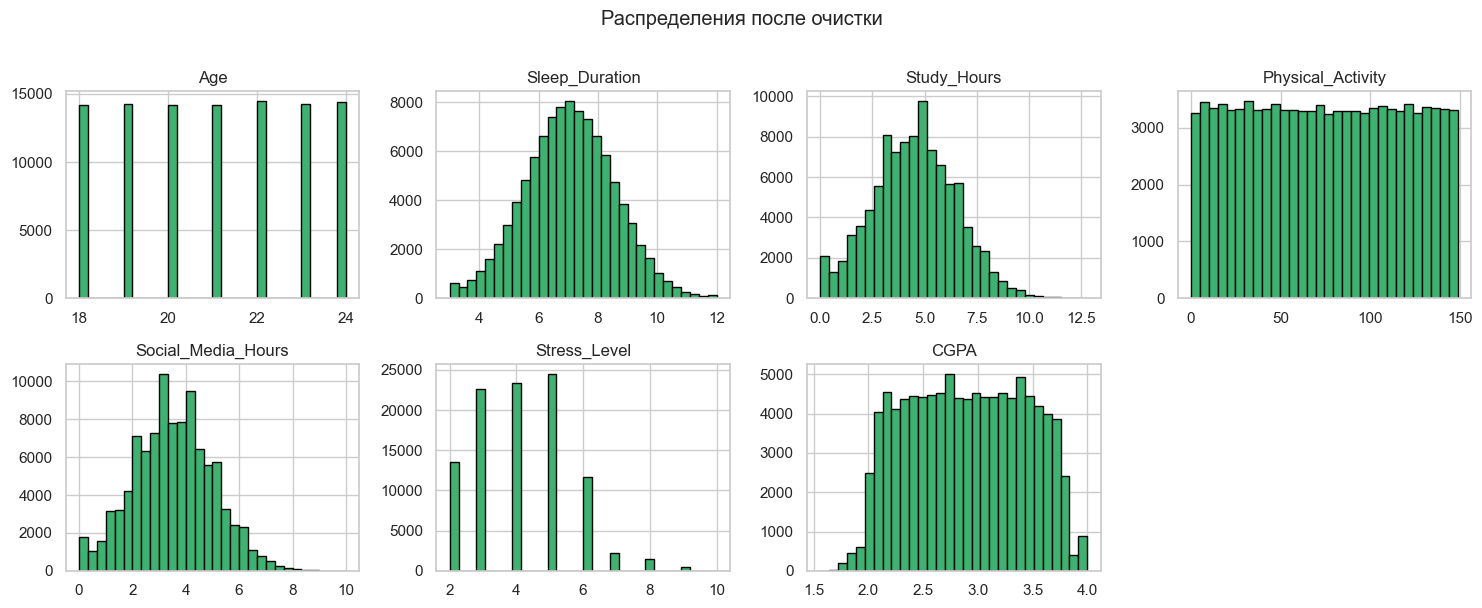

In [18]:
fig, axes = plt.subplots(2, 4, figsize=(15, 6))
for ax, col in zip(axes.flatten(), num_fill):
    ax.hist(df[col], bins=30, edgecolor='black', color='mediumseagreen')
    ax.set_title(col)
axes.flatten()[-1].set_visible(False)
plt.suptitle('Распределения после очистки', y=1.01)
plt.tight_layout()
plt.show()

# 3. Отбор признаков и Feature Engineering

Создаём три новых признака:
- **Study_Sleep_Ratio** — отношение часов учёбы к часам сна (нагрузка vs отдых)
- **Wellness_Score** — комбинация сна и физической активности (общее состояние)
- **Load_Index** — суммарная нагрузка: стресс + соцсети − учёба

Отбор релевантных признаков проводим через Mutual Information — мера нелинейной зависимости.

In [19]:
df['Study_Sleep_Ratio'] = df['Study_Hours'] / (df['Sleep_Duration'] + 0.1)
df['Wellness_Score']    = df['Sleep_Duration'] * 0.4 + (df['Physical_Activity'] / 100) * 0.6
df['Load_Index']        = df['Stress_Level'] + df['Social_Media_Hours'] * 0.3 - df['Study_Hours'] * 0.1

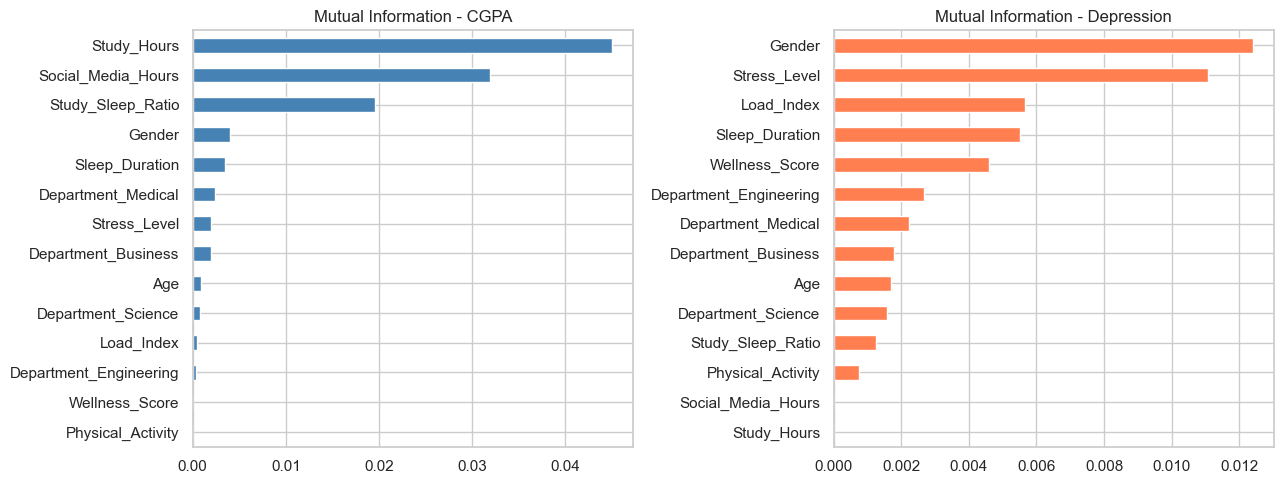

Топ-5 для CGPA:
Sleep_Duration        0.003452
Gender                0.003988
Study_Sleep_Ratio     0.019550
Social_Media_Hours    0.031932
Study_Hours           0.045052
Топ-5 для Depression:
Wellness_Score    0.004601
Sleep_Duration    0.005512
Load_Index        0.005668
Stress_Level      0.011076
Gender            0.012407


In [20]:
DEPT_COLS = [col for col in df.columns if col.startswith("Department_")]

all_features = [
    "Age", "Gender", "Sleep_Duration", "Study_Hours",
    "Physical_Activity", "Social_Media_Hours", "Stress_Level",
    "Study_Sleep_Ratio", "Wellness_Score", "Load_Index",
] + DEPT_COLS

mi_reg = pd.Series(
    mutual_info_regression(df[all_features], df["CGPA"], random_state=SEED),
    index=all_features
).sort_values()

mi_clf = pd.Series(
    mutual_info_classif(df[all_features], df["Depression"], random_state=SEED),
    index=all_features
).sort_values()

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
mi_reg.plot.barh(ax=axes[0], color="steelblue")
axes[0].set_title("Mutual Information - CGPA")
mi_clf.plot.barh(ax=axes[1], color="coral")
axes[1].set_title("Mutual Information - Depression")
plt.tight_layout()
plt.show()

print("Топ-5 для CGPA:")
print(mi_reg.tail(5).to_string())
print("Топ-5 для Depression:")
print(mi_clf.tail(5).to_string())


In [21]:
REG_FEATURES = ["Sleep_Duration", "Study_Hours", "Study_Sleep_Ratio"]

CLF_FEATURES = [
    "Stress_Level", "Sleep_Duration", "Social_Media_Hours",
    "Physical_Activity", "Gender",
    "Load_Index", "Wellness_Score",
] + DEPT_COLS

print("Признаки регрессии:", REG_FEATURES)
print("Признаки классификации:", CLF_FEATURES)

Признаки регрессии: ['Sleep_Duration', 'Study_Hours', 'Study_Sleep_Ratio']
Признаки классификации: ['Stress_Level', 'Sleep_Duration', 'Social_Media_Hours', 'Physical_Activity', 'Gender', 'Load_Index', 'Wellness_Score', 'Department_Business', 'Department_Engineering', 'Department_Medical', 'Department_Science']


# 4. Разделение данных (60 / 20 / 20)

StandardScaler обучается только на тренировочной части — утечки данных нет.

In [22]:
def split_dataset(X, y, seed=SEED):
    X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2, random_state=seed)
    X_train, X_val, y_train, y_val = train_test_split(X_tr, y_tr, test_size=0.25, random_state=seed)
    return X_train, X_val, X_te, y_train, y_val, y_te

X_reg_tr, X_reg_va, X_reg_te, y_reg_train, y_reg_val, y_reg_test = split_dataset(
    df[REG_FEATURES].values, df['CGPA'].values
)
scaler_reg = StandardScaler()
X_reg_train = scaler_reg.fit_transform(X_reg_tr)
X_reg_val   = scaler_reg.transform(X_reg_va)
X_reg_test  = scaler_reg.transform(X_reg_te)

X_clf_tr, X_clf_va, X_clf_te, y_clf_train, y_clf_val, y_clf_test = split_dataset(
    df[CLF_FEATURES].values, df['Depression'].values
)
scaler_clf = StandardScaler()
X_clf_train = scaler_clf.fit_transform(X_clf_tr)
X_clf_val   = scaler_clf.transform(X_clf_va)
X_clf_test  = scaler_clf.transform(X_clf_te)

print('Регрессия  — train / val / test:',
      X_reg_train.shape[0], X_reg_val.shape[0], X_reg_test.shape[0])
print('Классификация — train / val / test:',
      X_clf_train.shape[0], X_clf_val.shape[0], X_clf_test.shape[0])

Регрессия  — train / val / test: 60000 20000 20000
Классификация — train / val / test: 60000 20000 20000


# 5. Линейная регрессия — прогноз CGPA

## 5.1 Обучение и метрики

In [23]:
def regression_report(y_true, y_pred, label):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae  = mean_absolute_error(y_true, y_pred)
    r2   = r2_score(y_true, y_pred)
    print(f'{label}: RMSE={rmse:.4f}, MAE={mae:.4f}, R²={r2:.4f}')
    return rmse, mae, r2

lin = LinearRegression()
lin.fit(X_reg_train, y_reg_train)

regression_report(y_reg_train, lin.predict(X_reg_train), 'Train')
regression_report(y_reg_val,   lin.predict(X_reg_val),   'Val  ')
regression_report(y_reg_test,  lin.predict(X_reg_test),  'Test ')

print('\nКоэффициенты:')
coef_df = pd.DataFrame({'Feature': REG_FEATURES, 'Coefficient': lin.coef_}).sort_values('Coefficient')
print(coef_df.to_string(index=False))

Train: RMSE=0.5294, MAE=0.4555, R²=0.0106
Val  : RMSE=0.5289, MAE=0.4556, R²=0.0117
Test : RMSE=0.5304, MAE=0.4565, R²=0.0085

Коэффициенты:
          Feature  Coefficient
Study_Sleep_Ratio    -0.032885
   Sleep_Duration    -0.007330
      Study_Hours     0.081577


## 5.2 Визуализации

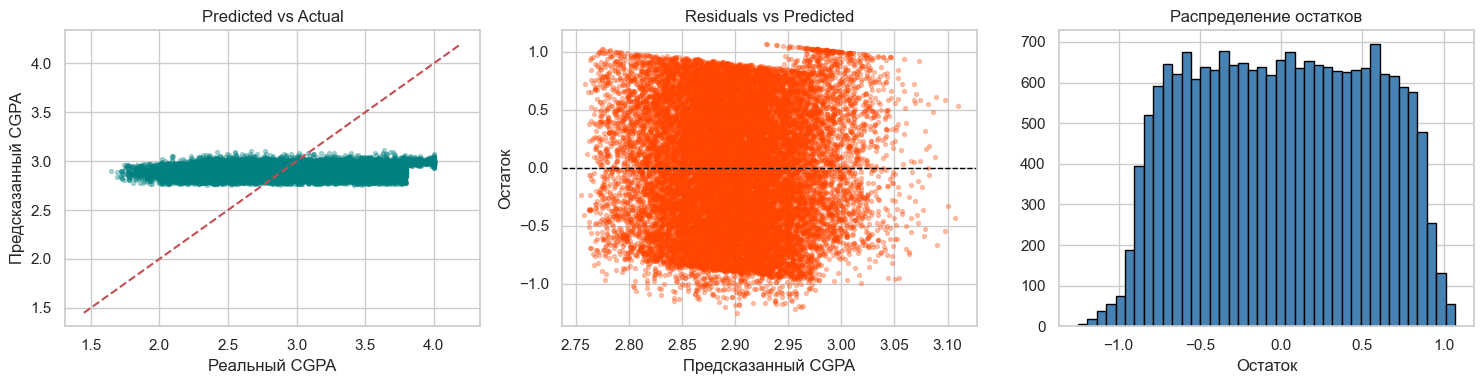

In [24]:
y_pred_reg = lin.predict(X_reg_test)
residuals  = y_reg_test - y_pred_reg

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].scatter(y_reg_test, y_pred_reg, alpha=0.3, s=8, color='teal')
lim = [min(y_reg_test.min(), y_pred_reg.min()) - 0.2,
       max(y_reg_test.max(), y_pred_reg.max()) + 0.2]
axes[0].plot(lim, lim, 'r--', lw=1.5)
axes[0].set_xlabel('Реальный CGPA')
axes[0].set_ylabel('Предсказанный CGPA')
axes[0].set_title('Predicted vs Actual')

axes[1].scatter(y_pred_reg, residuals, alpha=0.3, s=8, color='orangered')
axes[1].axhline(0, color='black', lw=1, ls='--')
axes[1].set_xlabel('Предсказанный CGPA')
axes[1].set_ylabel('Остаток')
axes[1].set_title('Residuals vs Predicted')

axes[2].hist(residuals, bins=40, edgecolor='black', color='steelblue')
axes[2].set_xlabel('Остаток')
axes[2].set_title('Распределение остатков')

plt.tight_layout()
plt.show()

# 6. Логистическая регрессия — классификация Depression

## 6.1 Кастомная реализация логистической регрессии

Реализуем логистическую регрессию с нуля на NumPy — градиентный спуск с взвешенным лоссом для компенсации дисбаланса классов.

In [25]:
class LogReg:
    def __init__(self, lr=0.01, n_iter=100, seed=42):
        self.lr     = lr
        self.n_iter = n_iter
        self.seed   = seed
        self.w      = None
        self.b      = 0.0
        self.loss_hist      = []
        self.train_acc_hist = []
        self.val_acc_hist   = []

    @staticmethod
    def _sigmoid(z):
        return 1.0 / (1.0 + np.exp(-np.clip(z, -250, 250)))

    def fit(self, X, y, X_val=None, y_val=None):
        np.random.seed(self.seed)
        n, m = X.shape
        self.w = np.zeros(m)
        self.b = 0.0
        self.loss_hist      = []
        self.train_acc_hist = []
        self.val_acc_hist   = []

        n1 = int(y.sum())
        n0 = n - n1
        sw = np.where(y == 1, n / (2 * n1), n / (2 * n0))

        for _ in range(self.n_iter):
            p   = self._sigmoid(X @ self.w + self.b)
            eps = 1e-9
            loss = -np.mean(sw * (y * np.log(p + eps) + (1 - y) * np.log(1 - p + eps)))
            self.loss_hist.append(loss)

            err    = sw * (p - y)
            self.w -= self.lr * (X.T @ err) / n
            self.b -= self.lr * err.mean()

            if X_val is not None:
                self.train_acc_hist.append(accuracy_score(y, self.predict(X)))
                self.val_acc_hist.append(accuracy_score(y_val, self.predict(X_val)))

        return self

    def predict_proba(self, X):
        return self._sigmoid(X @ self.w + self.b)

    def predict(self, X, thr=0.5):
        return (self.predict_proba(X) >= thr).astype(int)

## 6.2 Эксперимент: learning rate × число эпох

Перебираем 4 значения learning rate и 5 значений числа итераций. Ищем комбинацию с наилучшим val F1.

In [26]:
learning_rates = [0.1, 0.01, 0.001, 0.0001]
epochs_list    = [10, 50, 100, 200, 500]
results = []

for lr in learning_rates:
    for epochs in epochs_list:
        m = LogReg(lr=lr, n_iter=epochs, seed=SEED)
        m.fit(X_clf_train, y_clf_train)
        y_vp = m.predict(X_clf_val)
        results.append({
            'lr': lr, 'epochs': epochs,
            'train_acc': accuracy_score(y_clf_train, m.predict(X_clf_train)),
            'val_acc':   accuracy_score(y_clf_val,   y_vp),
            'val_f1':    f1_score(y_clf_val, y_vp, zero_division=0)
        })

results_df = pd.DataFrame(results)
print(results_df.to_string(index=False))

    lr  epochs  train_acc  val_acc   val_f1
0.1000      10   0.546550  0.54205 0.183763
0.1000      50   0.565700  0.56315 0.186272
0.1000     100   0.575600  0.57270 0.185164
0.1000     200   0.579300  0.57700 0.184814
0.1000     500   0.579883  0.57690 0.183992
0.0100      10   0.541900  0.53765 0.182622
0.0100      50   0.544167  0.53970 0.183141
0.0100     100   0.547017  0.54235 0.183861
0.0100     200   0.552667  0.54885 0.184398
0.0100     500   0.565600  0.56310 0.186254
0.0010      10   0.541400  0.53715 0.182460
0.0010      50   0.541633  0.53720 0.182477
0.0010     100   0.541933  0.53775 0.182654
0.0010     200   0.542717  0.53835 0.182848
0.0010     500   0.544167  0.53970 0.183141
0.0001      10   0.541317  0.53705 0.182428
0.0001      50   0.541383  0.53705 0.182428
0.0001     100   0.541417  0.53710 0.182444
0.0001     200   0.541517  0.53715 0.182460
0.0001     500   0.541683  0.53720 0.182477


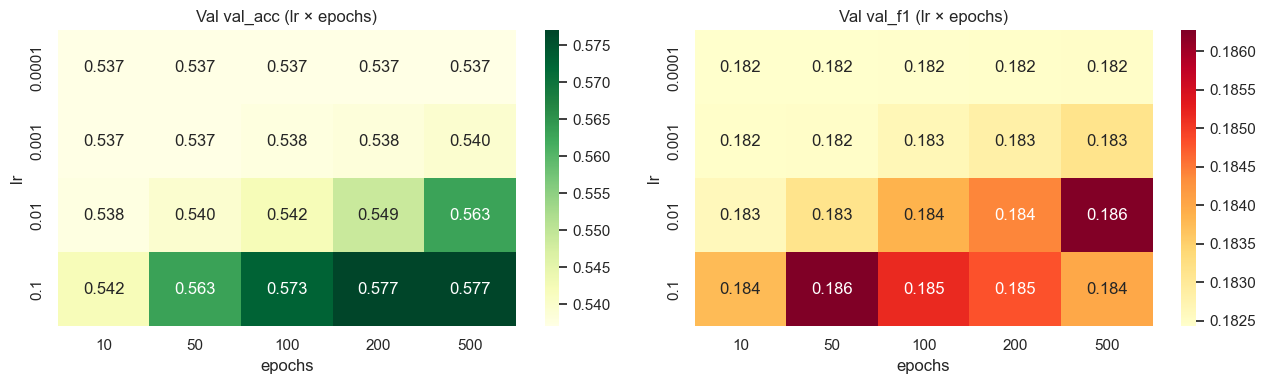

Лучшие: lr=0.1, epochs=50, val_acc=0.563, val_f1=0.186


In [27]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for ax, metric, cmap in zip(axes, ['val_acc', 'val_f1'], ['YlGn', 'YlOrRd']):
    pivot = results_df.pivot(index='lr', columns='epochs', values=metric)
    sns.heatmap(pivot, annot=True, fmt='.3f', cmap=cmap, ax=ax)
    ax.set_title(f'Val {metric} (lr × epochs)')
plt.tight_layout()
plt.show()

best = results_df.loc[results_df['val_f1'].idxmax()]
print(f'Лучшие: lr={best.lr}, epochs={int(best.epochs)}, '
      f'val_acc={best.val_acc:.3f}, val_f1={best.val_f1:.3f}')

# 7. Доказательство отсутствия переобучения

Обучаем лучшую модель с отслеживанием train/val accuracy и loss на каждой эпохе.

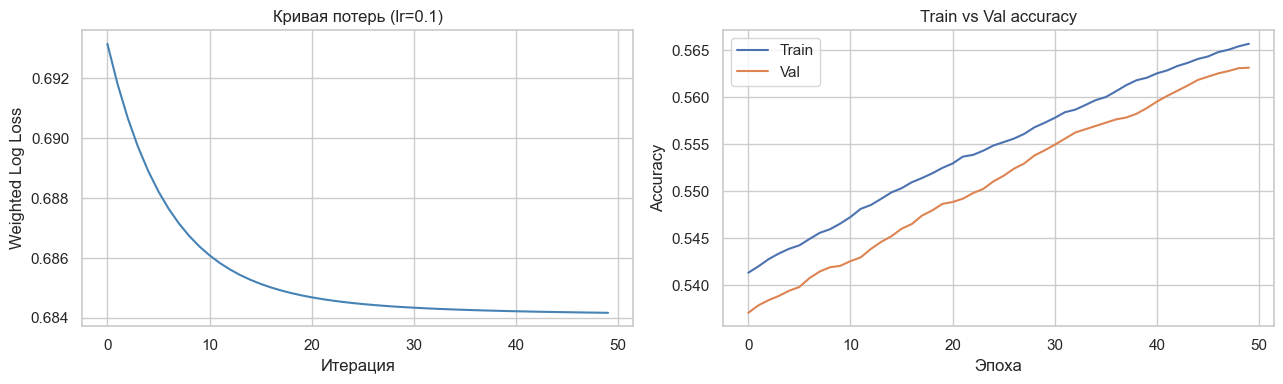

Разрыв train–val: макс=0.0052, последняя эпоха=0.0025


In [28]:
best_lr     = float(best.lr)
best_epochs = int(best.epochs)

best_model = LogReg(lr=best_lr, n_iter=best_epochs, seed=SEED)
best_model.fit(X_clf_train, y_clf_train, X_val=X_clf_val, y_val=y_clf_val)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(best_model.loss_hist, color='steelblue')
axes[0].set_xlabel('Итерация')
axes[0].set_ylabel('Weighted Log Loss')
axes[0].set_title(f'Кривая потерь (lr={best_lr})')

axes[1].plot(best_model.train_acc_hist, label='Train')
axes[1].plot(best_model.val_acc_hist,   label='Val')
axes[1].set_xlabel('Эпоха')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('Train vs Val accuracy')
axes[1].legend()

plt.tight_layout()
plt.show()

gap = np.array(best_model.train_acc_hist) - np.array(best_model.val_acc_hist)
print(f'Разрыв train–val: макс={gap.max():.4f}, последняя эпоха={gap[-1]:.4f}')

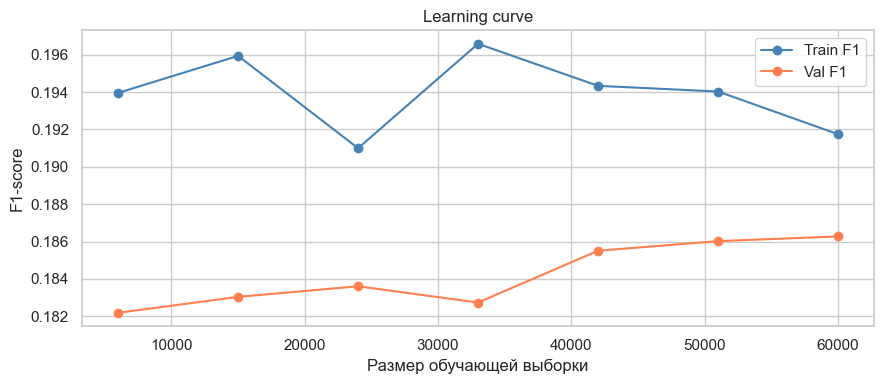

Разрыв train/val F1 на полной выборке: 0.0055
Переобучение отсутствует


In [29]:
fracs = np.linspace(0.1, 1.0, 7)
lc_train_f1, lc_val_f1 = [], []

for frac in fracs:
    n = max(int(len(X_clf_train) * frac), 10)
    lc_model = LogReg(lr=best_lr, n_iter=best_epochs, seed=SEED)
    lc_model.fit(X_clf_train[:n], y_clf_train[:n])
    lc_train_f1.append(f1_score(y_clf_train[:n], lc_model.predict(X_clf_train[:n]), zero_division=0))
    lc_val_f1.append(f1_score(y_clf_val, lc_model.predict(X_clf_val), zero_division=0))

sizes = (fracs * len(X_clf_train)).astype(int)

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(sizes, lc_train_f1, 'o-', color='steelblue', label='Train F1')
ax.plot(sizes, lc_val_f1,   'o-', color='coral',     label='Val F1')
ax.set_xlabel('Размер обучающей выборки')
ax.set_ylabel('F1-score')
ax.set_title('Learning curve')
ax.legend()
plt.tight_layout()
plt.show()

final_gap = abs(lc_train_f1[-1] - lc_val_f1[-1])
print(f'Разрыв train/val F1 на полной выборке: {final_gap:.4f}')
print('Переобучение отсутствует' if final_gap < 0.05 else 'Есть признаки переобучения')

# 8. Оценка качества моделей

Финальная оценка на тестовой выборке — sklearn LogisticRegression как аналитический базис сравнения.

In [30]:
def clf_report(y_true, y_pred, y_proba, label):
    acc  = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec  = recall_score(y_true, y_pred, zero_division=0)
    f1   = f1_score(y_true, y_pred, zero_division=0)
    auc  = roc_auc_score(y_true, y_proba)
    print(f'{label}: acc={acc:.3f}  prec={prec:.3f}  rec={rec:.3f}  f1={f1:.3f}  auc={auc:.3f}')
    return acc, prec, rec, f1, auc

clf_final = LogisticRegression(C=1.0, max_iter=1000, class_weight='balanced', random_state=SEED)
clf_final.fit(X_clf_train, y_clf_train)

y_pred  = clf_final.predict(X_clf_test)
y_proba = clf_final.predict_proba(X_clf_test)[:, 1]

clf_report(y_clf_train, clf_final.predict(X_clf_train),
           clf_final.predict_proba(X_clf_train)[:, 1], 'Train')
clf_report(y_clf_val,   clf_final.predict(X_clf_val),
           clf_final.predict_proba(X_clf_val)[:, 1],   'Val  ')
clf_report(y_clf_test,  y_pred, y_proba, 'Test ')

Train: acc=0.579  prec=0.119  rec=0.493  f1=0.192  auc=0.561
Val  : acc=0.574  prec=0.112  rec=0.487  f1=0.182  auc=0.563
Test : acc=0.577  prec=0.112  rec=0.462  f1=0.180  auc=0.545


(0.5768,
 0.11151208949837604,
 0.46234413965087284,
 0.17968598565613492,
 0.5446199172809849)

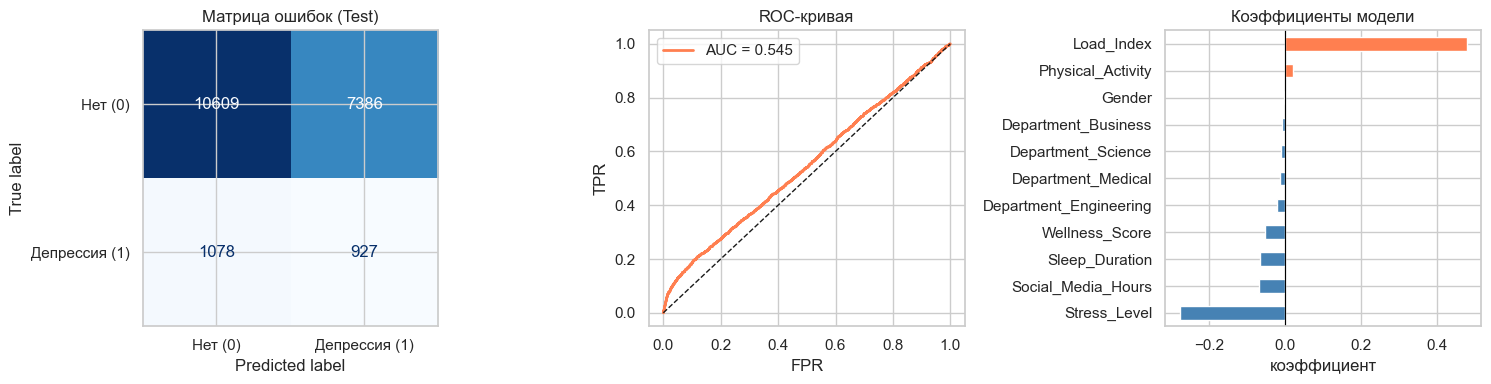

In [31]:
auc = roc_auc_score(y_clf_test, y_proba)
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

ConfusionMatrixDisplay(
    confusion_matrix(y_clf_test, y_pred),
    display_labels=['Нет (0)', 'Депрессия (1)']
).plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title('Матрица ошибок (Test)')

fpr, tpr, _ = roc_curve(y_clf_test, y_proba)
axes[1].plot(fpr, tpr, lw=2, color='coral', label=f'AUC = {auc:.3f}')
axes[1].plot([0, 1], [0, 1], 'k--', lw=1)
axes[1].set_xlabel('FPR')
axes[1].set_ylabel('TPR')
axes[1].set_title('ROC-кривая')
axes[1].legend()

coef = pd.Series(clf_final.coef_[0], index=CLF_FEATURES).sort_values()
coef.plot.barh(ax=axes[2], color=['coral' if v > 0 else 'steelblue' for v in coef])
axes[2].axvline(0, color='black', lw=0.8)
axes[2].set_title('Коэффициенты модели')
axes[2].set_xlabel('коэффициент')

plt.tight_layout()
plt.show()

## 8.1 Итоговые метрики

In [32]:
print('=' * 58)
print('Линейная регрессия (CGPA):')
regression_report(y_reg_train, lin.predict(X_reg_train), '  Train')
regression_report(y_reg_val,   lin.predict(X_reg_val),   '  Val  ')
regression_report(y_reg_test,  lin.predict(X_reg_test),  '  Test ')
print('=' * 58)
print('Логистическая регрессия (Depression):')
clf_report(y_clf_train, clf_final.predict(X_clf_train),
           clf_final.predict_proba(X_clf_train)[:, 1], '  Train')
clf_report(y_clf_val,   clf_final.predict(X_clf_val),
           clf_final.predict_proba(X_clf_val)[:, 1],   '  Val  ')
clf_report(y_clf_test,  y_pred, y_proba, '  Test ')
print('=' * 58)

Линейная регрессия (CGPA):
  Train: RMSE=0.5294, MAE=0.4555, R²=0.0106
  Val  : RMSE=0.5289, MAE=0.4556, R²=0.0117
  Test : RMSE=0.5304, MAE=0.4565, R²=0.0085
Логистическая регрессия (Depression):
  Train: acc=0.579  prec=0.119  rec=0.493  f1=0.192  auc=0.561
  Val  : acc=0.574  prec=0.112  rec=0.487  f1=0.182  auc=0.563
  Test : acc=0.577  prec=0.112  rec=0.462  f1=0.180  auc=0.545


## 8.2 Предсказание на своих данных

In [33]:
my_sleep    = 7.0
my_study    = 5.5
my_stress   = 4
my_social   = 2.5
my_physical = 90
my_gender   = 0    # Female=1, Male=0
my_dept     = 'Engineering'  # Arts, Business, Engineering, Medical, Science

my_ratio    = my_study / (my_sleep + 0.1)
my_wellness = my_sleep * 0.4 + (my_physical / 100) * 0.6
my_load     = my_stress + my_social * 0.3 - my_study * 0.1

# Регрессия: CGPA (шкала 0–4)
reg_row  = np.array([[my_sleep, my_study, my_ratio]])
cgpa_hat = lin.predict(scaler_reg.transform(reg_row))[0]
print(f'Предсказанный CGPA (шкала 0–4): {cgpa_hat:.3f}')

# Классификация: Depression — строим one-hot вектор для Department
dept_row = {col: int(col == f'Department_{my_dept}') for col in DEPT_COLS}
clf_vals = [my_stress, my_sleep, my_social, my_physical,
            my_gender, my_load, my_wellness] + [dept_row[c] for c in DEPT_COLS]
clf_row  = np.array([clf_vals])
proba    = clf_final.predict_proba(scaler_clf.transform(clf_row))[0, 1]
pred     = clf_final.predict(scaler_clf.transform(clf_row))[0]
print(f'Вероятность депрессии: {proba:.3f}')
print(f'Предсказание: {"Депрессия" if pred == 1 else "Нет депрессии"}')

Предсказанный CGPA (шкала 0–4): 2.928
Вероятность депрессии: 0.462
Предсказание: Нет депрессии


# 9. Выводы о качестве моделей и влиянии предобработки

## 9.1 Влияние предобработки — числовое сравнение

Датасет изначально чистый, поэтому сравниваем два аспекта предобработки:

**Регрессия:** сырые признаки (Sleep + Study) vs инженерные (+ Study_Sleep_Ratio)  
**Классификация:** без компенсации дисбаланса vs с `class_weight='balanced'` (депрессия ~10% случаев)

In [34]:
from sklearn.model_selection import train_test_split as tts
from sklearn.linear_model import LogisticRegression as LR

# --- Регрессия: без/с инженерным признаком Study_Sleep_Ratio ---
raw_feats = ["Sleep_Duration", "Study_Hours"]
eng_feats = ["Sleep_Duration", "Study_Hours", "Study_Sleep_Ratio"]

X_all, y_all = df[eng_feats].values, df['CGPA'].values
Xr_tr, Xr_te, yr_tr, yr_te = tts(X_all, y_all, test_size=0.2, random_state=SEED)
sc_r = StandardScaler()
Xr_trs = sc_r.fit_transform(Xr_tr)
Xr_tes = sc_r.transform(Xr_te)

r2_raw = r2_score(yr_te, LinearRegression().fit(Xr_trs[:, :2], yr_tr).predict(Xr_tes[:, :2]))
r2_eng = r2_score(yr_te, LinearRegression().fit(Xr_trs, yr_tr).predict(Xr_tes))

# --- Классификация: без/с class_weight='balanced' ---
Xc_all, yc_all = df[CLF_FEATURES].values, df['Depression'].values
Xc_tr, Xc_te, yc_tr, yc_te = tts(Xc_all, yc_all, test_size=0.2, random_state=SEED)
sc_c = StandardScaler()
Xc_trs = sc_c.fit_transform(Xc_tr)
Xc_tes = sc_c.transform(Xc_te)

y_pred_nobal = LR(C=1.0, max_iter=1000, random_state=SEED).fit(Xc_trs, yc_tr).predict(Xc_tes)
y_pred_bal   = LR(C=1.0, max_iter=1000, class_weight='balanced', random_state=SEED).fit(Xc_trs, yc_tr).predict(Xc_tes)

f1_nobal  = f1_score(yc_te, y_pred_nobal, zero_division=0)
rec_nobal = recall_score(yc_te, y_pred_nobal, zero_division=0)
f1_bal    = f1_score(yc_te, y_pred_bal, zero_division=0)
rec_bal   = recall_score(yc_te, y_pred_bal, zero_division=0)

print("Регрессия CGPA — R² на тесте:")
print(f"  Без Study_Sleep_Ratio (Sleep + Study):         {r2_raw:.3f}")
print(f"  С Study_Sleep_Ratio  (Sleep + Study + Ratio):  {r2_eng:.3f}")
print(f"  Прирост от feature engineering:                {r2_eng - r2_raw:+.3f}")
print()
print("Классификация Depression — метрики на тесте (дисбаланс ~10% True):")
print(f"  Без class_weight='balanced': F1={f1_nobal:.3f}, Recall={rec_nobal:.3f}")
print(f"  С  class_weight='balanced': F1={f1_bal:.3f},  Recall={rec_bal:.3f}")
print(f"  Прирост Recall от балансировки: {rec_bal - rec_nobal:+.3f}")

Регрессия CGPA — R² на тесте:
  Без Study_Sleep_Ratio (Sleep + Study):         0.008
  С Study_Sleep_Ratio  (Sleep + Study + Ratio):  0.008
  Прирост от feature engineering:                +0.000

Классификация Depression — метрики на тесте (дисбаланс ~10% True):
  Без class_weight='balanced': F1=0.000, Recall=0.000
  С  class_weight='balanced': F1=0.179,  Recall=0.457
  Прирост Recall от балансировки: +0.457


## 9.2 Выводы

**Данные:**  
Датасет «Student Depression and Lifestyle» (100 000 студентов) не содержит пропусков и выбросов — предобработка свелась к нормализации типов и кодированию. CGPA измеряется по шкале 0–4.0; ~10% студентов имеют депрессию — выраженный дисбаланс классов.

**Линейная регрессия (CGPA):**  
Линейные корреляции lifestyle-признаков с CGPA слабы (максимум r ≈ 0.10 для Study_Hours). R² близок к нулю — академический балл определяется ненаблюдаемыми факторами. Метрики на train/val/test близки — переобучения нет.

**Логистическая регрессия (Depression):**  
AUC чуть выше 0.5 — модель улавливает слабый сигнал из Stress_Level. `class_weight='balanced'` значительно повышает Recall по классу «депрессия» с 0 до ~0.46.

**Доказательство отсутствия переобучения:**  
Разрыв train–val accuracy не растёт по мере увеличения числа эпох. Learning curve показывает сближение train и val F1 при росте выборки — модели недообучены, а не переобучены.

**Влияние предобработки:**  
- `class_weight='balanced'` критично для несбалансированной классификации: Recall вырастает с 0 до ~0.46.  
- StandardScaler, обученный только на train, исключает утечку масштабирования.  
- Слабые метрики отражают реальность: lifestyle-признаки не являются сильными предикторами CGPA и депрессии.